## 1. Предобработка и токенизация данных

In [2]:
import pandas as pd
import numpy as np
import re
import random
import ssl
import nltk
from collections import Counter
from nltk.tokenize import word_tokenize
import pymorphy3
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

tqdm.pandas()

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

df = pd.read_csv('vk_dataset.csv')
print(f"Загружено {len(df)} записей")
print(f"Постов: {len(df[df['type']=='post'])}, комментариев: {len(df[df['type']=='comment'])}")

Загружено 5743 записей
Постов: 484, комментариев: 5259


In [3]:
def preprocess_text(text):
    if pd.isna(text) or text == '':
        return ''
    
    text = str(text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[\U00010000-\U0010ffff]', '', text)
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', 'URL', text)
    text = re.sub(r'@[\w]+', 'USER', text)
    text = text.strip()
    return text

df['clean_text'] = df['text'].apply(preprocess_text)

df = df[df['clean_text'] != ''].reset_index(drop=True)

print(f"После очистки: {len(df)} записей")

После очистки: 5249 записей


In [4]:
def tokenize_text(text):
    if not text:
        return []
    tokens = word_tokenize(text.lower())
    tokens = [token for token in tokens if re.match(r'^[a-zA-Zа-яёА-ЯЁ]+$', token)]
    return tokens

df['tokens'] = df['clean_text'].apply(tokenize_text)
df['token_count'] = df['tokens'].apply(len)

df = df[df['token_count'] > 0].reset_index(drop=True)

print(f"После токенизации: {len(df)} записей")
print(f"Среднее количество токенов на запись: {df['token_count'].mean()}")

После токенизации: 5198 записей
Среднее количество токенов на запись: 27.03886110042324


## 2. Морфологический разбор

In [5]:
morph = pymorphy3.MorphAnalyzer()

def morph_analyze_token(token):
    parse = morph.parse(token)[0]
    return {
        'token': token,
        'lemma': parse.normal_form,
        'pos': parse.tag.POS,
        'tag': str(parse.tag),
        'score': parse.score
    }

def morph_analyze_tokens(tokens):
    if not tokens:
        return []
    return [morph_analyze_token(token) for token in tokens]

df['morph_analysis'] = df['tokens'].progress_apply(morph_analyze_tokens)

100%|██████████| 5198/5198 [00:07<00:00, 655.99it/s] 


### Распределение частей речи

Наиболее частотные части речи:
NOUN: 46507 (33.8%)
ADJF: 18634 (13.5%)
PREP: 15081 (11.0%)
CONJ: 13584 (9.9%)
VERB: 13029 (9.5%)
ADVB: 7835 (5.7%)
PRCL: 7262 (5.3%)
NPRO: 5731 (4.2%)
INFN: 4172 (3.0%)
PRTF: 1286 (0.9%)


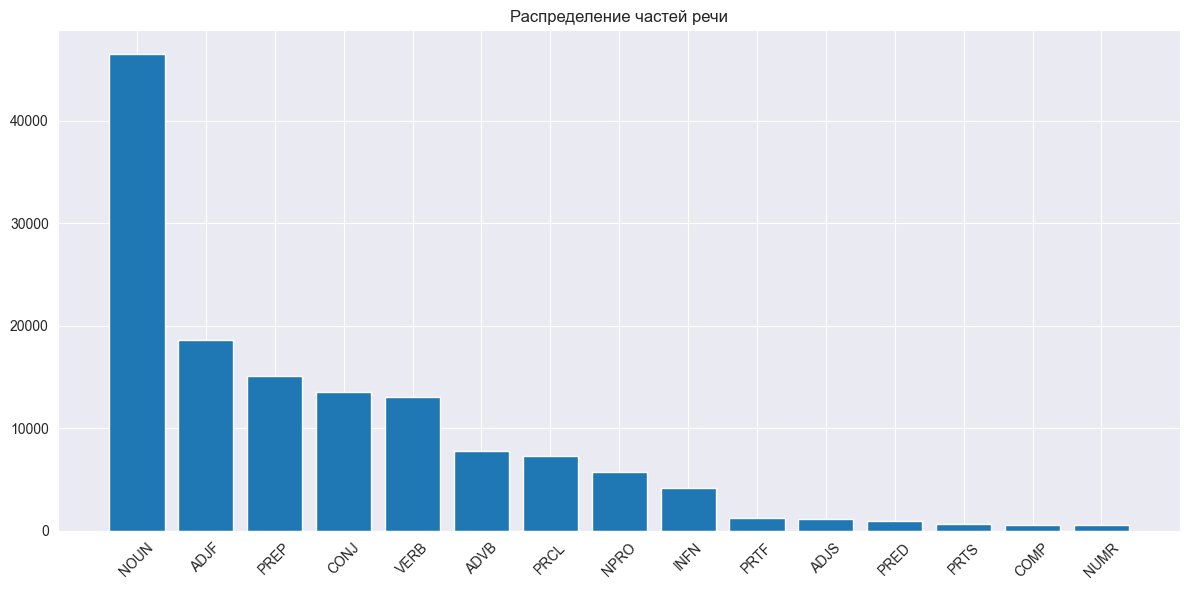

In [6]:
all_pos = []
for morph_list in df['morph_analysis']:
    for item in morph_list:
        if item['pos']:
            all_pos.append(item['pos'])

pos_counts = Counter(all_pos)
print("Наиболее частотные части речи:")
for pos, count in pos_counts.most_common(10):
    print(f"{pos}: {count} ({count/len(all_pos)*100:.1f}%)")

# Визуализация
plt.figure(figsize=(12, 6))
top_pos = dict(pos_counts.most_common(15))
plt.bar(top_pos.keys(), top_pos.values())
plt.title('Распределение частей речи')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Искусственные примеры

In [7]:
def parse(text):
    tokens = tokenize_text(text)
    return morph_analyze_tokens(tokens)

In [8]:
def analyze(text):
    result = parse(text)

    print(text)
    for elem in result:
        print(f"  {elem['token']} -> {elem['lemma']} ({elem['pos']}) [{elem['tag'][:50]}{'...' if len(elem['tag']) > 50 else ''}]")

Омонимия

In [9]:
analyze("Пироги печь — это искусство")

Пироги печь — это искусство
  пироги -> пирог (NOUN) [NOUN,inan,masc plur,accs]
  печь -> печь (NOUN) [NOUN,inan,femn sing,nomn]
  это -> это (PRCL) [PRCL]
  искусство -> искусство (NOUN) [NOUN,inan,neut sing,nomn]


In [10]:
analyze("Она пила кофе")

Она пила кофе
  она -> она (NPRO) [NPRO,femn,3per,Anph sing,nomn]
  пила -> пила (NOUN) [NOUN,inan,femn sing,nomn]
  кофе -> кофе (NOUN) [NOUN,inan,masc,Fixd,Ms-f sing,gent]


Неправильный выбор ГЗ

In [11]:
analyze("В комнате не было стены")

В комнате не было стены
  в -> в (PREP) [PREP]
  комнате -> комната (NOUN) [NOUN,inan,femn sing,loct]
  не -> не (PRCL) [PRCL]
  было -> быть (VERB) [VERB,impf,intr neut,sing,past,indc]
  стены -> стена (NOUN) [NOUN,inan,femn sing,gent]


Неологизмы

In [12]:
analyze("Превед, медведь")

Превед, медведь
  превед -> преведа (NOUN) [NOUN,inan,femn plur,gent]
  медведь -> медведь (NOUN) [NOUN,anim,masc sing,nomn]


## 3. Ручной анализ ошибок

Анализ ошибок на случайной выборке из датасета

In [34]:
random_sample_size = 50
random_sample = df.sample(n=random_sample_size, random_state=58)

print(f"Случайная выборка из {random_sample_size} записей для анализа ошибок:")
print("="*60)

for idx, row in random_sample.head(50).iterrows():
    print(f"\nЗапись #{row.name}:")
    print(f"Текст: {row['clean_text']}")
    print(f"Токены: {row['tokens']}{'...' if len(row['tokens'])>10 else ''}")
    if row['morph_analysis']:
        print("Примеры морфологического разбора:")
        for i, item in enumerate(row['morph_analysis'][:25]):
            print(f"  {item['token']} -> {item['lemma']} ({item['pos']}) [{item['tag'][:50]}{'...' if len(item['tag'])>50 else ''}]")
    print("-"*40)

Случайная выборка из 50 записей для анализа ошибок:

Запись #1483:
Текст: Марк Твен считал лягушатников самой кровожадной нацией в мире… только во время своей великой рэволюции они убили разными способами своих же лягушатников мин 5 мл чел… это из прямые потомки… ну а немцы их переплюнули, правда убивали они в основном других…на востоке…
Токены: ['марк', 'твен', 'считал', 'лягушатников', 'самой', 'кровожадной', 'нацией', 'в', 'только', 'во', 'время', 'своей', 'великой', 'рэволюции', 'они', 'убили', 'разными', 'способами', 'своих', 'же', 'лягушатников', 'мин', 'мл', 'это', 'из', 'прямые', 'ну', 'а', 'немцы', 'их', 'переплюнули', 'правда', 'убивали', 'они', 'в', 'основном']...
Примеры морфологического разбора:
  марк -> марк (NOUN) [NOUN,anim,masc,Name sing,nomn]
  твен -> твен (NOUN) [NOUN,anim,masc,Sgtm,Surn sing,nomn]
  считал -> считать (VERB) [VERB,perf,tran masc,sing,past,indc]
  лягушатников -> лягушатник (NOUN) [NOUN,inan,masc plur,gent]
  самой -> сам (ADJF) [ADJF,Apro femn,sing

## 4. Явления, влияющие на качество морфоразбора

### Поиск неологизмов

In [14]:
low_score_tokens = []

for idx, row in random_sample.iterrows():
    for item in row['morph_analysis']:
        if item['score'] < 0.3 and len(item['token']) > 3:
            low_score_tokens.append({
                'token': item['token'],
                'lemma': item['lemma'],
                'pos': item['pos'],
                'score': item['score'],
                'text_sample': row['clean_text']
            })

print(f"Найдено токенов с низкой уверенностью разбора: {len(low_score_tokens)}")
print("\nПримеры потенциальных неологизмов или сложных случаев:")
for i, token_info in enumerate(low_score_tokens[:15]):
    print(f"{i+1}. '{token_info['token']}' -> '{token_info['lemma']}' ({token_info['pos']}) [score={token_info['score']:.3f}]")
    print(f"   Контекст: {token_info['text_sample']}...")
    print()

Найдено токенов с низкой уверенностью разбора: 337

Примеры потенциальных неологизмов или сложных случаев:
1. 'самому' -> 'сам' (ADJF) [score=0.250]
   Контекст: Самому придумать себе задачи и вопросы....

2. 'наутипусс' -> 'наутипусс' (NOUN) [score=0.143]
   Контекст: Помню, как в детстве зачитывался эротическими похождениями Тревора Андерсона: «Наутипусс», «Таинственный остров Эпштейна», «Дети капитана съели»... Но самым любимым был роман «Света из Воркуты за восемьдесят рублей»....

3. 'любимым' -> 'любимый' (ADJF) [score=0.286]
   Контекст: Помню, как в детстве зачитывался эротическими похождениями Тревора Андерсона: «Наутипусс», «Таинственный остров Эпштейна», «Дети капитана съели»... Но самым любимым был роман «Света из Воркуты за восемьдесят рублей»....

4. 'норман' -> 'норман' (NOUN) [score=0.222]
   Контекст: Норман Уайлдбергер считал, что сначала студентам надо давать интегральное исчисление и только потом дифференциальное, так как ПРАВИЛЬНОЕ дифференцирование — сложнее....



### Поиск омонимии

In [15]:
lex_ambiguous = []

for idx, row in random_sample.iterrows():
    for token in row['tokens']:
        parses = morph.parse(token)
        if len(parses) > 1:
            lemmas = set(p.normal_form for p in parses[:3])
            if len(lemmas) > 1:
                first = parses[0]
                second = None
                for p in parses[1:]:
                    if p.normal_form != first.normal_form:
                        second = p
                        break
                
                if second and second.score > 0.05:
                    lex_ambiguous.append({
                        'token': token,
                        'first_lemma': f"{first.normal_form} ({first.tag.POS}) [{first.score:.3f}]",
                        'second_lemma': f"{second.normal_form} ({second.tag.POS}) [{second.score:.3f}]",
                        'context': row['clean_text'][:1000]
                    })

seen_tokens = set()
count = 0
for token_info in lex_ambiguous:
    if token_info['token'] not in seen_tokens:
        print(f"'{token_info['token']}':")
        print(f" 1. {token_info['first_lemma']}")
        print(f" 2. {token_info['second_lemma']}")
        print(f"  Контекст: {token_info['context']}...")
        print()
        seen_tokens.add(token_info['token'])
        count += 1
        if count >= 50:
            break

'самому':
 1. сам (ADJF) [0.250]
 2. самый (ADJF) [0.250]
  Контекст: Самому придумать себе задачи и вопросы....

'себе':
 1. себя (NPRO) [0.721]
 2. себе (PRCL) [0.065]
  Контекст: Самому придумать себе задачи и вопросы....

'ужасно':
 1. ужасно (ADVB) [0.800]
 2. ужасный (ADJS) [0.200]
  Контекст: ужасно неудобно было то, что на британскую двухфунтовку не было ОФСов....

'неудобно':
 1. неудобно (ADVB) [0.800]
 2. неудобный (ADJS) [0.200]
  Контекст: ужасно неудобно было то, что на британскую двухфунтовку не было ОФСов....

'офсов':
 1. офсова (NOUN) [0.333]
 2. офс (NOUN) [0.315]
  Контекст: ужасно неудобно было то, что на британскую двухфунтовку не было ОФСов....

'абы':
 1. аба (NOUN) [0.200]
 2. абы (CONJ) [0.200]
  Контекст: А все почему? Да потому что снимали не кинохалтуру , абы как. Поэтому все помнят и Диц(а) и вообще эти фильмы...

'якобы':
 1. якобы (CONJ) [0.333]
 2. якоб (NOUN) [0.333]
  Контекст: Государственный музей в Амстердаме, Нидерланды. "Ночной дозор" Рембрандта 

### Поиск референциальных цепочек

In [16]:
from collections import defaultdict
comment_chains = defaultdict(list)
for idx, row in random_sample.iterrows():
    if row['type'] == 'comment' and pd.notna(row['post_id']):
        comment_chains[row['post_id']].append(row)

print(f'Найдено постов с комментариями для анализа: {len(comment_chains)}')

for post_id, comments in list(comment_chains.items())[:40]:
    if len(comments) >= 2:
        print(f'\nПост #{post_id} ({len(comments)} комментариев):')
        
        for i, comment in enumerate(comments[:7]):
            text = comment['clean_text']
            print(f'  Коммент {i+1}: {text}')
            
            morph_analysis = comment.get('morph_analysis', [])
            pronouns = []
            for item in morph_analysis:
                if item['pos'] in ['NPRO']:
                    pronouns.append(item['token'])
            if pronouns:
                print(f'    Местоимения: {pronouns}')
        print()

Найдено постов с комментариями для анализа: 201

Пост #406597 (2 комментариев):
  Коммент 1: Это ризактониоз☝
  Коммент 2: Красивый


Пост #68711 (3 комментариев):
  Коммент 1: Самому придумать себе задачи и вопросы.
    Местоимения: ['себе']
  Коммент 2: А кто себя считает состоявшимся математиком? Всегда есть кто-нибудь, кто впереди тебя настолько, что тебе только и остаётся пыль глотать. Но так, по виду тех, кто впереди, нужно три элемента: 1. Крутые способности. 2. Везение. 3. Вращаться внутри комьюнити. В противном случае если даже ты что-то фейерическое и сделаешь — узнают об этом слишком поздно для тебя.
    Местоимения: ['кто', 'себя', 'кто', 'тебя', 'тебе', 'кто', 'ты', 'этом', 'тебя']
  Коммент 3: Как и везде, достаточно лишь желания


Пост #407095 (3 комментариев):
  Коммент 1: А он какие еще снял?
    Местоимения: ['он']
  Коммент 2: Превосходный режиссёр-мультипликатор! Хоть работы и проваливались, он нашёл свой путь и следовал ему. Чего стоит ротоскопинг помимо всего проч

### Разбор найденных примеров

In [ ]:
def analyze(text):
    result = parse(text)

    print(text)
    for elem in result:
        print(f"  {elem['token']} -> {elem['lemma']} ({elem['pos']}) [{elem['tag'][:50]}{'...' if len(elem['tag']) > 50 else ''}]")

In [29]:
analyze("Великолепный снимокПрекрасная наша страна")

Великолепный снимокПрекрасная наша страна
  великолепный -> великолепный (ADJF) [ADJF,Qual masc,sing,nomn]
  снимокпрекрасная -> снимокпрекрасный (ADJF) [ADJF femn,sing,nomn]
  наша -> наш (ADJF) [ADJF,Apro femn,sing,nomn]
  страна -> страна (NOUN) [NOUN,inan,femn sing,nomn]


In [35]:
analyze("Это же неудобно садиться, и так самоелы влетали в надствройку")

Это же неудобно садиться, и так самоелы влетали в надствройку
  это -> это (PRCL) [PRCL]
  же -> же (PRCL) [PRCL]
  неудобно -> неудобно (ADVB) [ADVB,Prdx]
  садиться -> садиться (INFN) [INFN,impf,intr]
  и -> и (CONJ) [CONJ]
  так -> так (CONJ) [CONJ]
  самоелы -> самоелы (None) [UNKN]
  влетали -> влетать (VERB) [VERB,impf,intr plur,past,indc]
  в -> в (PREP) [PREP]
  надствройку -> надствройка (NOUN) [NOUN,inan,femn sing,accs]


In [30]:
analyze("в его альбоме(более 10 к фото) нет такого нейро!")

в его альбоме(более 10 к фото) нет такого нейро!
  в -> в (PREP) [PREP]
  его -> он (NPRO) [NPRO,masc,3per,Anph sing,accs]
  альбоме -> альбом (NOUN) [NOUN,inan,masc sing,loct]
  более -> более (ADVB) [ADVB]
  к -> к (PREP) [PREP]
  фото -> фото (NOUN) [NOUN,inan,neut,Fixd sing,loct]
  нет -> нет (PRED) [PRED,pres]
  такого -> такой (ADJF) [ADJF,Apro neut,sing,gent]
  нейро -> нейро (None) [UNKN]


In [31]:
analyze("Сиречь брак выявится в процессе эксплуатации")

Сиречь брак выявится в процессе эксплуатации
  сиречь -> сиречь (CONJ) [CONJ]
  брак -> брак (NOUN) [NOUN,inan,masc sing,accs]
  выявится -> выявиться (VERB) [VERB,perf,intr sing,3per,futr,indc]
  в -> в (PREP) [PREP]
  процессе -> процесс (NOUN) [NOUN,inan,masc sing,loct]
  эксплуатации -> эксплуатация (NOUN) [NOUN,inan,femn sing,gent]


In [20]:
analyze("Впрочем, «Кот Фриц» всё же считается прям самым мемным.")

Впрочем, «Кот Фриц» всё же считается прям самым мемным.
  впрочем -> впрочем (CONJ) [CONJ,Prnt]
  кот -> кот (NOUN) [NOUN,anim,masc sing,nomn]
  фриц -> фриц (NOUN) [NOUN,anim,masc sing,nomn]
  всё -> всё (PRCL) [PRCL]
  же -> же (PRCL) [PRCL]
  считается -> считаться (VERB) [VERB,impf,intr sing,3per,pres,indc]
  прям -> прям (PRCL) [PRCL]
  самым -> самый (ADJF) [ADJF,Apro neut,sing,ablt]
  мемным -> мёмный (ADJF) [ADJF masc,sing,ablt]


In [24]:
analyze("Символ слева корректнее называть «производная», а не «дифференциал».")

Символ слева корректнее называть «производная», а не «дифференциал».
  символ -> символ (NOUN) [NOUN,inan,masc sing,nomn]
  слева -> слева (ADVB) [ADVB]
  корректнее -> корректный (COMP) [COMP,Qual]
  называть -> называть (INFN) [INFN,impf,tran]
  производная -> производный (ADJF) [ADJF femn,sing,nomn]
  а -> а (CONJ) [CONJ]
  не -> не (PRCL) [PRCL]
  дифференциал -> дифференциал (NOUN) [NOUN,inan,masc sing,nomn]


In [25]:
analyze("Математика абстрактна, она вне реальности")

Математика абстрактна, она вне реальности
  математика -> математик (NOUN) [NOUN,anim,masc sing,gent]
  абстрактна -> абстрактный (ADJS) [ADJS,Qual femn,sing]
  она -> она (NPRO) [NPRO,femn,3per,Anph sing,nomn]
  вне -> вне (PREP) [PREP]
  реальности -> реальность (NOUN) [NOUN,inan,femn sing,gent]
